<a href="https://colab.research.google.com/github/lgrando1/PID2026/blob/main/PID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### O Gêmeo Digital: Entendendo a Planta Térmica de 1ª Ordem

No nosso laboratório no Colab, o bloco de código `planta_aquecedor` atua como o **Gêmeo Digital** do sistema físico. Ele não é o controlador; ele é o "universo" onde o controlador atua. O objetivo desta função é responder matematicamente à seguinte pergunta: *"Se eu ligar a resistência do aquecedor nesta potência agora, qual será a temperatura exata no próximo segundo?"*

Para entender como o código simula a física, precisamos dominar a nomenclatura e a fórmula utilizadas.

---

### 1. Dicionário de Variáveis (A Nomenclatura)

* **`T_atual` (Temperatura Atual):** É a nossa **PV** (Variável de Processo) no momento presente (instante $k$). É o valor lido pelo sensor de temperatura antes de qualquer nova ação.
* **`T_nova` (Temperatura Nova):** É o estado futuro da planta (instante $k+1$). É o resultado final do cálculo matemático após a energia do aquecedor agir durante um pequeno intervalo de tempo.
* **`U_atual` (Sinal de Controle):** É a nossa **MV** (Variável Manipulada) ou o esforço do atuador. Representa a potência do PWM enviada à resistência do aquecedor (variando de 0.0% a 100.0%).
* **`dt` ($\Delta t$ - Passo de Tempo):** É o tempo de amostragem lógico. Representa a "janela de tempo" entre o quadro atual e o próximo quadro da simulação.
* **`tau` ($\tau$ - Constante de Tempo / Inércia):** Representa o "peso" ou a lentidão do sistema. Um tanque de água de 10.000 litros tem um `tau` gigantesco comparado a um copo d'água. Ele dita o quão resistente a temperatura é a mudanças bruscas.
* **`K` (Ganho Estático):** É o fator de conversão de potência para temperatura. No código, $K = 1.0$, o que significa que 100% de potência do atuador resulta teoricamente em 100°C de temperatura máxima na estabilização.
* **`ruido`:** Um valor sorteado estatisticamente a cada *loop* para simular a interferência eletromagnética (sujeira) que cabos e sensores reais sofrem na indústria.

---

### 2. A Tradução: Do Mundo Contínuo para o Código



Na teoria clássica (livros e diagramas de blocos), um sistema térmico simples é representado por uma Função de Transferência de 1ª ordem no domínio de Laplace:
$$G(s) = \frac{K}{\tau s + 1}$$

O microcontrolador (e o nosso código Python) não entende a variável complexa $s$ (que implica tempo infinito e contínuo). Ele entende cálculos passo a passo. Por isso, aplicamos a **Discretização de Euler** para transformar aquela função de transferência na nossa "Equação de Diferenças":

```python
T_nova = T_atual + (dt / tau) * (K * U_atual - T_atual) + ruido
```

---

### 3. Dissecando a Equação (Passo a Passo)

Vamos quebrar a linha de código principal da planta para entender a lógica física que ela esconde:

#### Bloco A: O Ponto de Partida
> `T_nova = T_atual + ...`

A temperatura do próximo segundo sempre parte da temperatura de agora. A inércia física impede que a temperatura "teleporte" de 20°C para 50°C instantaneamente.

#### Bloco B: O Balanço de Energia (Aquecer vs. Esfriar)
> `... (K * U_atual - T_atual) ...`

Esta é a força motriz térmica.
* Se o aquecedor está ligado no máximo (`U_atual` = 100) e a temperatura da água ainda está fria (`T_atual` = 20), o resultado dessa conta é alto e positivo (+80). O sistema ganha muita energia e esquenta.
* Se o aquecedor for desligado (`U_atual` = 0) e a água estiver quente (`T_atual` = 50), o resultado dessa conta fica negativo (-50). O sistema perde energia para o ambiente e esfria.

#### Bloco C: O Efeito da Inércia e do Tempo
> `... (dt / tau) * ...`

A energia calculada no Bloco B não entra no sistema de uma vez só. Ela é multiplicada por uma pequena fração: o tempo que passou (`dt`) dividido pelo peso térmico da planta (`tau`).
* **Se a Inércia (`tau`) for muito grande:** O denominador é alto, a fração fica minúscula e a temperatura sobe extremamente devagar.
* **Se o Tempo (`dt`) avança:** A cada *loop* do código, uma nova fatia dessa energia é injetada, subindo a temperatura "degrau por degrau" até estabilizar.

#### Bloco D: O Choque de Realidade
> `... + ruido`

Ao final do cálculo puramente matemático e limpo, adicionamos o ruído estocástico. Isso contamina a leitura do "gêmeo digital", garantindo que o controlador que nós programarmos nas próximas aulas tenha que lidar com um desafio idêntico ao de uma malha industrial real com sensores imperfeitos.

# 🚀 Laboratório de Sintonia - Sprint 2: SmartFlow
Este notebook simula a dinâmica de controle de fluxo/temperatura da nossa planta física.

**Objetivos:**
1. Observar o efeito destrutivo do *Chattering* no controle Liga/Desliga (ON/OFF).
2. Entender a função da Histerese na proteção do hardware.
3. Implementar a anatomia de um controlador PID digital com bloqueio *Anti-Windup*.
4. Analisar graficamente o *Rise Time*, *Overshoot* e *Settling Time*.

Para executar o ambiente na nuvem, utilize o [Google Colab](https://colab.research.google.com/).

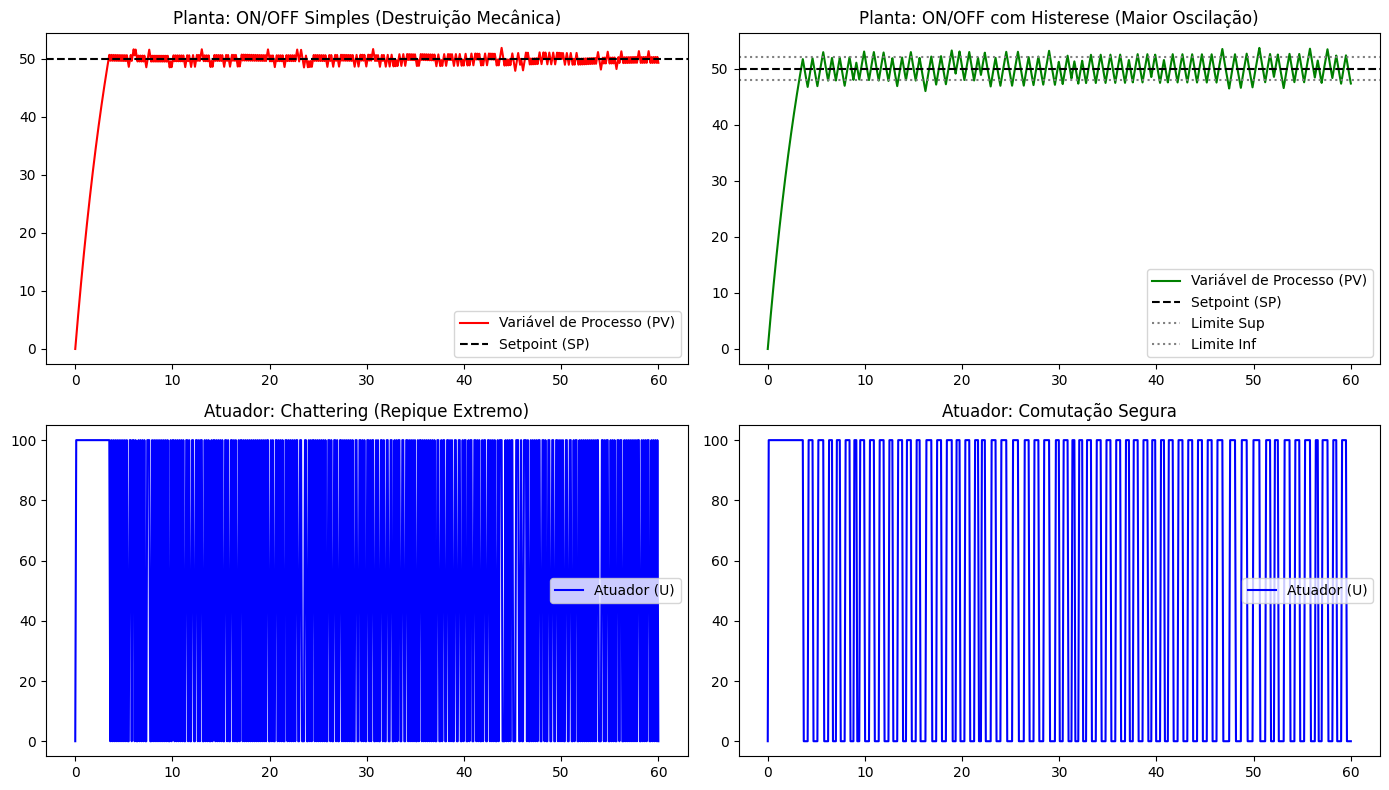

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÂMETROS GERAIS E DA PLANTA
# ==========================================
dt = 0.1                # Passo de tempo (Delta t) em segundos
tempo_total = 60.0      # Tempo total de simulação
k_passos = int(tempo_total / dt)
t = np.linspace(0, tempo_total, k_passos)

SP = 50.0               # Setpoint (Alvo desejado)
tau = 5.0               # Inércia da Planta (Tau) - o quão "pesado" é o sistema
potencia_max = 100.0    # Saturação física do atuador (ex: Bomba a 100%)

# ==========================================
# 2. SIMULAÇÃO: ON/OFF SEM HISTERESE (Chattering)
# ==========================================
PV_off = np.zeros(k_passos)
U_off = np.zeros(k_passos)

for k in range(1, k_passos):
    # Sensor real sempre tem um leve ruído elétrico
    ruido = np.random.normal(0, 0.5)
    leitura_atual = PV_off[k-1] + ruido

    # Lógica ON/OFF Simples
    if leitura_atual < SP:
        U_off[k] = potencia_max
    else:
        U_off[k] = 0.0

    # Equação de Diferenças da Planta (Física)
    PV_off[k] = PV_off[k-1] + (dt / tau) * (U_off[k] - PV_off[k-1])

# ==========================================
# 3. SIMULAÇÃO: ON/OFF COM HISTERESE (Proteção)
# ==========================================
PV_hist = np.zeros(k_passos)
U_hist = np.zeros(k_passos)
H = 2.0  # Banda de Histerese de 2 unidades

estado_atuador = 0.0

for k in range(1, k_passos):
    ruido = np.random.normal(0, 0.5)
    leitura_atual = PV_hist[k-1] + ruido

    # Lógica ON/OFF com Histerese
    if leitura_atual < (SP - H):
        estado_atuador = potencia_max
    elif leitura_atual > (SP + H):
        estado_atuador = 0.0

    U_hist[k] = estado_atuador
    PV_hist[k] = PV_hist[k-1] + (dt / tau) * (U_hist[k] - PV_hist[k-1])

# ==========================================
# 4. PLOTAGEM DOS GRÁFICOS
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Gráficos Sem Histerese
axs[0,0].plot(t, PV_off, 'r-', label='Variável de Processo (PV)')
axs[0,0].axhline(SP, color='k', linestyle='--', label='Setpoint (SP)')
axs[0,0].set_title('Planta: ON/OFF Simples (Destruição Mecânica)')
axs[0,0].legend()

axs[1,0].plot(t, U_off, 'b-', label='Atuador (U)')
axs[1,0].set_title('Atuador: Chattering (Repique Extremo)')
axs[1,0].legend()

# Gráficos Com Histerese
axs[0,1].plot(t, PV_hist, 'g-', label='Variável de Processo (PV)')
axs[0,1].axhline(SP, color='k', linestyle='--', label='Setpoint (SP)')
axs[0,1].axhline(SP+H, color='gray', linestyle=':', label='Limite Sup')
axs[0,1].axhline(SP-H, color='gray', linestyle=':', label='Limite Inf')
axs[0,1].set_title('Planta: ON/OFF com Histerese (Maior Oscilação)')
axs[0,1].legend()

axs[1,1].plot(t, U_hist, 'b-', label='Atuador (U)')
axs[1,1].set_title('Atuador: Comutação Segura')
axs[1,1].legend()

plt.tight_layout()
plt.show()

## O Algoritmo Contínuo: Controlador PID e Anti-Windup
Nesta etapa, os *Squads* devem alterar os ganhos ($K_p$, $K_i$, $K_d$) para realizar a sintonia empírica. Observe como o termo Integral (I) remove o Erro de Regime Permanente, mas pode causar *Overshoot*.

Atenção especial à trava algorítmica do **Anti-Windup**, requisito obrigatório da nossa entrega de software.

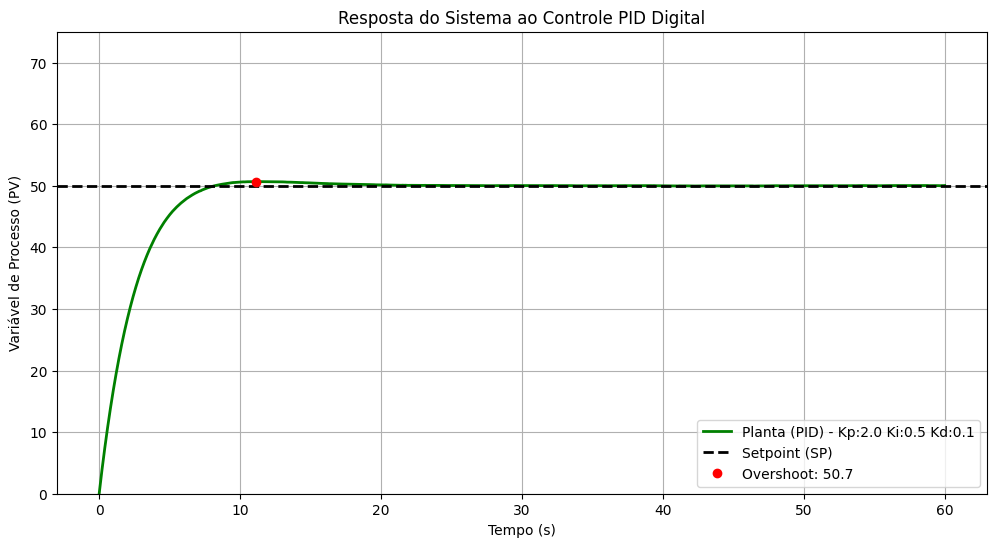

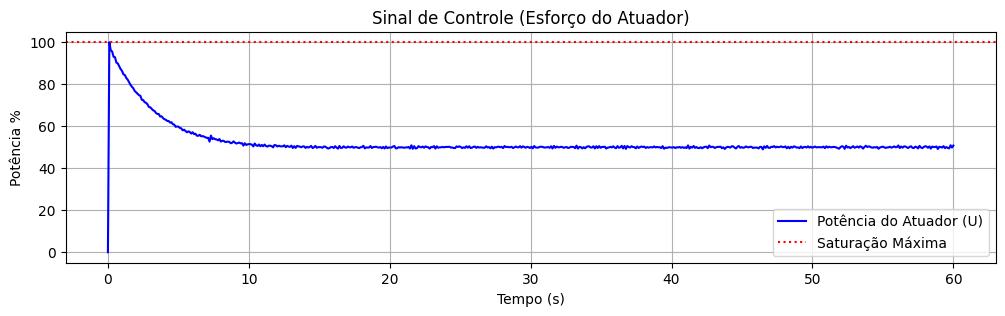

In [ ]:
# ==========================================
# 1. PARÂMETROS DE SINTONIA (SQUADS, ALTEREM AQUI!)
# ==========================================
Kp = 2.0    # Ganho Proporcional (Mola - Presente)
Ki = 0.5    # Ganho Integral (Trator - Passado)
Kd = 0.1    # Ganho Derivativo (Freio - Futuro)

# ==========================================
# 2. INICIALIZAÇÃO DO CONTROLADOR PID
# ==========================================
PV_pid = np.zeros(k_passos)
U_pid = np.zeros(k_passos)

erro_acumulado = 0.0
erro_anterior = 0.0

for k in range(1, k_passos):
    # Simulando a leitura do sensor (com leve ruído para testar a Derivada)
    ruido = np.random.normal(0, 0.1)
    leitura_atual = PV_pid[k-1] + ruido

    # Cálculo do Erro Contínuo
    erro = SP - leitura_atual

    # --- ANATOMIA DO PID ---

    # Ação Proporcional (P)
    P_out = Kp * erro

    # Ação Integral (I) com regra dos retângulos
    erro_acumulado += erro * dt
    I_out = Ki * erro_acumulado

    # Ação Derivativa (D)
    taxa_variacao = (erro - erro_anterior) / dt
    D_out = Kd * taxa_variacao
    erro_anterior = erro

    # Sinal de Controle Teórico (Pode pedir 5000%)
    U_teorico = P_out + I_out + D_out

    # --- PROTEÇÃO DE HARDWARE: ANTI-WINDUP ---
    # Saturação física: A bomba/aquecedor não passa de 100% nem cai abaixo de 0%
    if U_teorico > potencia_max:
        U_real = potencia_max
        # Bloqueia o acúmulo da integral se estiver saturado no máximo
        erro_acumulado -= erro * dt
    elif U_teorico < 0.0:
        U_real = 0.0
        # Bloqueia o acúmulo da integral se estiver saturado no mínimo
        erro_acumulado -= erro * dt
    else:
        U_real = U_teorico

    U_pid[k] = U_real

    # Equação de Diferenças da Planta (Física reagindo ao PID)
    PV_pid[k] = PV_pid[k-1] + (dt / tau) * (U_pid[k] - PV_pid[k-1])

# ==========================================
# 3. PLOTAGEM DO GRÁFICO DE SINTONIA
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(t, PV_pid, 'g-', linewidth=2, label=f'Planta (PID) - Kp:{Kp} Ki:{Ki} Kd:{Kd}')
plt.axhline(SP, color='k', linestyle='--', linewidth=2, label='Setpoint (SP)')

# Marcação visual do Overshoot (pico máximo)
pico_maximo = np.max(PV_pid)
if pico_maximo > SP:
    plt.plot(t[np.argmax(PV_pid)], pico_maximo, 'ro', label=f'Overshoot: {pico_maximo:.1f}')

plt.title('Resposta do Sistema ao Controle PID Digital')
plt.xlabel('Tempo (s)')
plt.ylabel('Variável de Processo (PV)')
plt.ylim(0, SP * 1.5)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Para visualizar o sinal enviado ao atuador:
plt.figure(figsize=(12, 3))
plt.plot(t, U_pid, 'b-', label='Potência do Atuador (U)')
plt.axhline(potencia_max, color='r', linestyle=':', label='Saturação Máxima')
plt.title('Sinal de Controle (Esforço do Atuador)')
plt.xlabel('Tempo (s)')
plt.ylabel('Potência %')
plt.legend()
plt.grid(True)
plt.show()

# Estrutura e Funcionamento do Modelo de Simulação

O modelo computacional divide-se em duas esferas principais: a simulação da planta física e a lógica do controlador. Abaixo estão descritos os mecanismos fundamentais que regem o código.

**1. Dinâmica da Planta (Inércia e Avanço no Tempo)**
A equação de diferenças `PV[k] = PV[k-1] + (dt / tau) * (U[k] - PV[k-1])` representa o avanço discreto no tempo. O estado da variável de processo no instante atual (`PV[k]`) é igual ao estado no instante anterior (`PV[k-1]`), acrescido da energia injetada pelo atuador (`U[k]`). Essa taxa de variação é atenuada pela inércia inerente ao sistema físico (`tau`) ao longo do tempo de amostragem (`dt`). É o ponto de conversão entre o modelo físico contínuo e a simulação de software.

**2. Ruído de Medição e Sensores**
A inserção de ruído estatístico nas leituras (`ruido = np.random.normal(0, 0.1)`) simula o comportamento imperfeito de sensores em campo (interferências eletromagnéticas, imprecisão). Esta característica é vital para testar a robustez do algoritmo, permitindo observar na prática o surgimento de *chattering* (comutação destrutiva) no controle Liga/Desliga sem histerese, bem como o impacto negativo da ação derivativa frente a flutuações de alta frequência.

**3. Anatomia do Algoritmo PID**
O núcleo do controlador calcula o esforço de controle dividindo-o em três respostas distintas:
* **Proporcional (`P_out = Kp * erro`):** Resposta baseada na magnitude instantânea do erro atual.
* **Integral (`erro_acumulado += erro * dt`):** Soma iterativa das fatias de erro multiplicadas pelo tempo. É o mecanismo responsável por continuar elevando o sinal de controle até a completa eliminação do erro de regime permanente.
* **Derivativa (`taxa_variacao = (erro - erro_anterior) / dt`):** Análise da velocidade de aproximação em relação ao setpoint. Atua reduzindo a potência preventivamente para mitigar ou eliminar o sobressinal (*overshoot*).

**4. Saturação Física e Algoritmo Anti-Windup**
O cálculo matemático (`U_teorico`) pode gerar demandas infinitas de potência, enquanto o atuador físico possui um limite estrito (ex: `potencia_max = 100%`). Se o controlador comandar uma potência além do limite físico, o sistema entra em saturação.
Para evitar que o termo integral continue somando erros indefinidamente durante este período (fenômeno conhecido como *Integral Windup*), aplica-se uma trava algorítmica:
```python
if U_teorico > potencia_max:
    U[k] = potencia_max
    erro_acumulado -= erro * dt # Reverte a integração do ciclo
```
Esta lógica garante que o termo integral seja congelado nos limites do atuador, impedindo acúmulos irreais na memória e garantindo que o sistema recupere o controle imediatamente quando o erro mudar de direção.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# SIMULADOR INTERATIVO SMARTFLOW (COLAB) - MODOS P, PI, PD, PID
# ==========================================

def simular_controle(modo, Kp, Ki, Kd, histerese):
    # Parâmetros da Planta
    dt = 0.1
    tempo_total = 60.0
    k_passos = int(tempo_total / dt)
    t = np.linspace(0, tempo_total, k_passos)

    SP = 50.0               # Setpoint
    tau = 5.0               # Inércia
    potencia_max = 100.0    # Saturação máxima

    PV = np.zeros(k_passos)
    U = np.zeros(k_passos)

    erro_acumulado = 0.0
    erro_anterior = 0.0

    # Filtra os ganhos dependendo do modo selecionado
    _Kp = Kp if modo in ['P', 'PI', 'PD', 'PID'] else 0.0
    _Ki = Ki if modo in ['PI', 'PID'] else 0.0
    _Kd = Kd if modo in ['PD', 'PID'] else 0.0

    for k in range(1, k_passos):
        # Ruído do sensor (maior no ON/OFF para demonstrar o chattering)
        ruido = np.random.normal(0, 0.5) if modo == 'ON/OFF' else np.random.normal(0, 0.1)
        leitura_atual = PV[k-1] + ruido
        erro = SP - leitura_atual

        if modo == 'ON/OFF':
            # Lógica Liga/Desliga com Histerese
            if leitura_atual < (SP - histerese):
                U[k] = potencia_max
            elif leitura_atual > (SP + histerese):
                U[k] = 0.0
            else:
                U[k] = U[k-1] # Mantém o estado anterior dentro da banda

        else:
            # --- ANATOMIA DO CONTROLADOR (P, PI, PD, PID) ---
            P_out = _Kp * erro

            erro_acumulado += erro * dt
            I_out = _Ki * erro_acumulado

            taxa_variacao = (erro - erro_anterior) / dt
            D_out = _Kd * taxa_variacao
            erro_anterior = erro

            U_teorico = P_out + I_out + D_out

            # --- ANTI-WINDUP ---
            if U_teorico > potencia_max:
                U[k] = potencia_max
                if _Ki > 0: # Só bloqueia se houver ação integral
                    erro_acumulado -= erro * dt
            elif U_teorico < 0.0:
                U[k] = 0.0
                if _Ki > 0:
                    erro_acumulado -= erro * dt
            else:
                U[k] = U_teorico

        # Equação de Diferenças da Planta (Física)
        PV[k] = PV[k-1] + (dt / tau) * (U[k] - PV[k-1])

    # --- CONTROLE DE VISIBILIDADE DA INTERFACE ---
    if modo == 'ON/OFF':
        Kp_slider.layout.display = 'none'
        Ki_slider.layout.display = 'none'
        Kd_slider.layout.display = 'none'
        H_slider.layout.display = 'flex'
    elif modo == 'P':
        Kp_slider.layout.display = 'flex'
        Ki_slider.layout.display = 'none'
        Kd_slider.layout.display = 'none'
        H_slider.layout.display = 'none'
    elif modo == 'PI':
        Kp_slider.layout.display = 'flex'
        Ki_slider.layout.display = 'flex'
        Kd_slider.layout.display = 'none'
        H_slider.layout.display = 'none'
    elif modo == 'PD':
        Kp_slider.layout.display = 'flex'
        Ki_slider.layout.display = 'none'
        Kd_slider.layout.display = 'flex'
        H_slider.layout.display = 'none'
    elif modo == 'PID':
        Kp_slider.layout.display = 'flex'
        Ki_slider.layout.display = 'flex'
        Kd_slider.layout.display = 'flex'
        H_slider.layout.display = 'none'

    # --- PLOTAGEM ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Gráfico da Planta (PV)
    ax1.plot(t, PV, 'g-', lw=2, label='Variável de Processo (PV)')
    ax1.axhline(SP, color='k', linestyle='--', lw=2, label='Setpoint (SP)')

    if modo == 'ON/OFF':
        ax1.axhline(SP + histerese, color='gray', linestyle=':', label='Limite Superior (Histerese)')
        ax1.axhline(SP - histerese, color='gray', linestyle=':', label='Limite Inferior (Histerese)')
    else:
        pico_maximo = np.max(PV)
        if pico_maximo > SP:
            ax1.plot(t[np.argmax(PV)], pico_maximo, 'ro', label=f'Overshoot: {pico_maximo:.1f}')

    ax1.set_title(f'Resposta do Sistema - Modo: {modo}')
    ax1.set_ylabel('Temperatura / Nível')
    ax1.set_ylim(0, SP * 1.5)
    ax1.legend(loc='lower right')
    ax1.grid(True)

    # Gráfico do Atuador (U)
    ax2.plot(t, U, 'b-', lw=2, label='Esforço do Atuador (U)')
    ax2.set_title('Sinal de Controle')
    ax2.set_xlabel('Tempo (s)')
    ax2.set_ylabel('Potência (%)')
    ax2.set_ylim(-10, potencia_max + 10)
    ax2.legend(loc='upper right')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Interface com Sliders (ipywidgets)
modo_dropdown = widgets.Dropdown(
    options=['ON/OFF', 'P', 'PI', 'PD', 'PID'],
    value='PID',
    description='Controle:'
)
Kp_slider = widgets.FloatSlider(value=2.0, min=0.0, max=20.0, step=0.5, description='Kp (P):', continuous_update=False)
Ki_slider = widgets.FloatSlider(value=0.5, min=0.0, max=5.0, step=0.1, description='Ki (I):', continuous_update=False)
Kd_slider = widgets.FloatSlider(value=0.1, min=0.0, max=2.0, step=0.1, description='Kd (D):', continuous_update=False)
H_slider = widgets.FloatSlider(value=2.0, min=0.0, max=10.0, step=0.5, description='Histerese:', continuous_update=False)

# Renderiza a interface interativa
out = widgets.interactive_output(simular_controle, {
    'modo': modo_dropdown,
    'Kp': Kp_slider,
    'Ki': Ki_slider,
    'Kd': Kd_slider,
    'histerese': H_slider
})

painel_controles = widgets.VBox([modo_dropdown, Kp_slider, Ki_slider, Kd_slider, H_slider])
display(widgets.HBox([painel_controles, out]))

# Parte 2 - Laboratório de Controle: Causalidade Dinâmica em Tempo Real


Este laboratório virtual simula uma planta térmica de primeira ordem e constrói a evolução do controle clássico. O modelo computacional divide-se em duas esferas principais: a simulação da planta física (Gêmeo Digital) e a lógica do controlador.

## 1. A Planta Física e a Inércia (Gêmeo Digital)
A modelagem do sistema físico incorpora a inércia térmica (`tau = 20.0`). A discretização explícita de Euler traduz o tempo contínuo para o software, demonstrando matematicamente que a variável de processo (temperatura) não reage de forma instantânea à potência máxima do atuador. A inserção de ruído estatístico nas leituras simula o comportamento imperfeito de sensores em campo (interferências eletromagnéticas, imprecisão), característica vital para testar a robustez dos algoritmos de controle.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# PLANTA FÍSICA (GÊMEO DIGITAL)
# ==============================================================================
def planta_aquecedor(T_atual, U_atual, ruido_amp, dt):
    """
    Simulação de um sistema térmico de 1ª ordem.
    Equação Contínua: G(s) = K / (tau*s + 1)
    """
    tau = 20.0  # Constante de tempo (Inércia Térmica)
    K = 1.0     # Ganho estático (Para 100% de PWM, sobe 100 graus teóricos)

    ruido = np.random.uniform(-ruido_amp, ruido_amp)

    # Discretização explícita (Euler) da equação diferencial
    T_nova = T_atual + (dt / tau) * (K * U_atual - T_atual) + ruido
    return T_nova

## 2. Anatomia dos Algoritmos de Controle e Proteções Físicas


O núcleo do controlador calcula o esforço de controle com base no erro (Setpoint - Variável de Processo). As diferentes abordagens apresentam vantagens teóricas e limitações físicas:

* **Controle ON/OFF e Chattering:** A lógica binária aplica 100% de potência se o valor estiver abaixo do alvo e 0% se ultrapassar. Devido ao ruído natural dos sensores, a leitura flutua na fronteira do setpoint, forçando comutações frenéticas. Este fenômeno, conhecido como *chattering*, causa desgaste severo e destruição de atuadores mecânicos.


* **Histerese:** Para proteger o hardware, estabelece-se uma banda morta ao redor do alvo. O atuador é preservado e comuta em intervalos seguros, mas a variável de processo é forçada a oscilar continuamente, impossibilitando a estabilização precisa.

* **Ação Proporcional [P] e Erro de Regime:** Atua de forma análoga a uma mola matemática. A potência diminui proporcionalmente à aproximação do alvo. Consequentemente, a força corretiva se iguala às perdas do sistema antes de atingir o setpoint exato, resultando em um distanciamento crônico denominado Erro de Regime Permanente.

* **Ação Integral [I] e Overshoot:** Introduz memória ao sistema acumulando o erro ao longo do tempo. Esta integração força o atuador a eliminar completamente o erro de regime. No entanto, a energia acumulada frequentemente faz com que a variável ultrapasse o setpoint antes de estabilizar, gerando o sobressinal (*overshoot*).

* **Saturação Física e Anti-Windup:** O cálculo matemático do PID pode exigir potência infinita, mas o atuador físico possui um limite estrito (ex: 100%). O fenômeno de *Integral Windup* ocorre quando a ação integral continua somando erros durante a saturação. O código implementa o grampo algorítmico de **Anti-Windup**, bloqueando o acúmulo irreal na memória para garantir a recuperação imediata do controle.


* **Ação Derivativa [D] e a Amplificação de Ruído:** Calcula a taxa de variação (velocidade) do erro, atuando como um freio preditivo que corta a potência antes do setpoint para evitar o overshoot. Contudo, a equação matemática interpreta qualquer ruído elétrico do sensor como uma aceleração altíssima, gerando picos agressivos que podem desestabilizar o sistema e danificar equipamentos industriais.

In [ ]:
# ==============================================================================
# ALGORITMOS DE CONTROLE
# ==============================================================================
def simular_controle(modo, Kp=0, Ki=0, Kd=0, histerese=0, ruido_amp=0.5):
    passos = 150
    dt = 1.0  # Tempo de amostragem explícito (Conecta com a integral/derivada real)
    SP = 50.0

    T = np.zeros(passos)
    U = np.zeros(passos)
    Erro_hist = np.zeros(passos)

    T[0] = 20.0
    integral = 0.0
    erro_anterior = SP - T[0]

    for k in range(1, passos):
        T_anterior = T[k-1]

        # 1. Leitura do Sensor e Cálculo do Erro
        erro = SP - T_anterior
        Erro_hist[k] = erro

        # 2. Lógica do Controlador
        if modo == 'ON/OFF':
            U[k] = 100.0 if T_anterior < SP else 0.0

        elif modo == 'HISTERESE':
            # Decisão baseada diretamente na PV vs SP (Evita confusão conceitual)
            if T_anterior < (SP - histerese):
                U[k] = 100.0
            elif T_anterior > (SP + histerese):
                U[k] = 0.0
            else:
                U[k] = U[k-1] # Retenção de estado

        elif modo in ['PID', 'PID_CAOS']:
            # A Matemática Pura (Tempo Discreto)
            integral += erro * dt
            derivada = (erro - erro_anterior) / dt

            # O que a matemática pede (Pode pedir infinito)
            U_raw = (Kp * erro) + (Ki * integral) + (Kd * derivada)

            # O que o mundo físico aceita (Saturação 0 a 100%)
            U[k] = max(0.0, min(100.0, U_raw))

            # Anti-Windup (O grampo algorítmico)
            if U_raw > 100.0 or U_raw < 0.0:
                integral -= erro * dt # Desfaz o acúmulo irreal

            erro_anterior = erro

        # 3. Atualização da Planta Física
        T[k] = planta_aquecedor(T[k-1], U[k], ruido_amp, dt)

    return T, U, Erro_hist

## 3. Análise Gráfica e Causalidade Dinâmica


Abaixo, a simulação percorre seis cenários fundamentais para demonstrar o comportamento dinâmico do controle em malha fechada. Observe a relação entre a Variável de Processo (linha azul), o Setpoint (linha vermelha tracejada) e o esforço exigido do Atuador (área verde). A análise gráfica expõe a evolução desde a instabilidade binária até a sintonia fina do PID e os limites práticos do ganho derivativo.

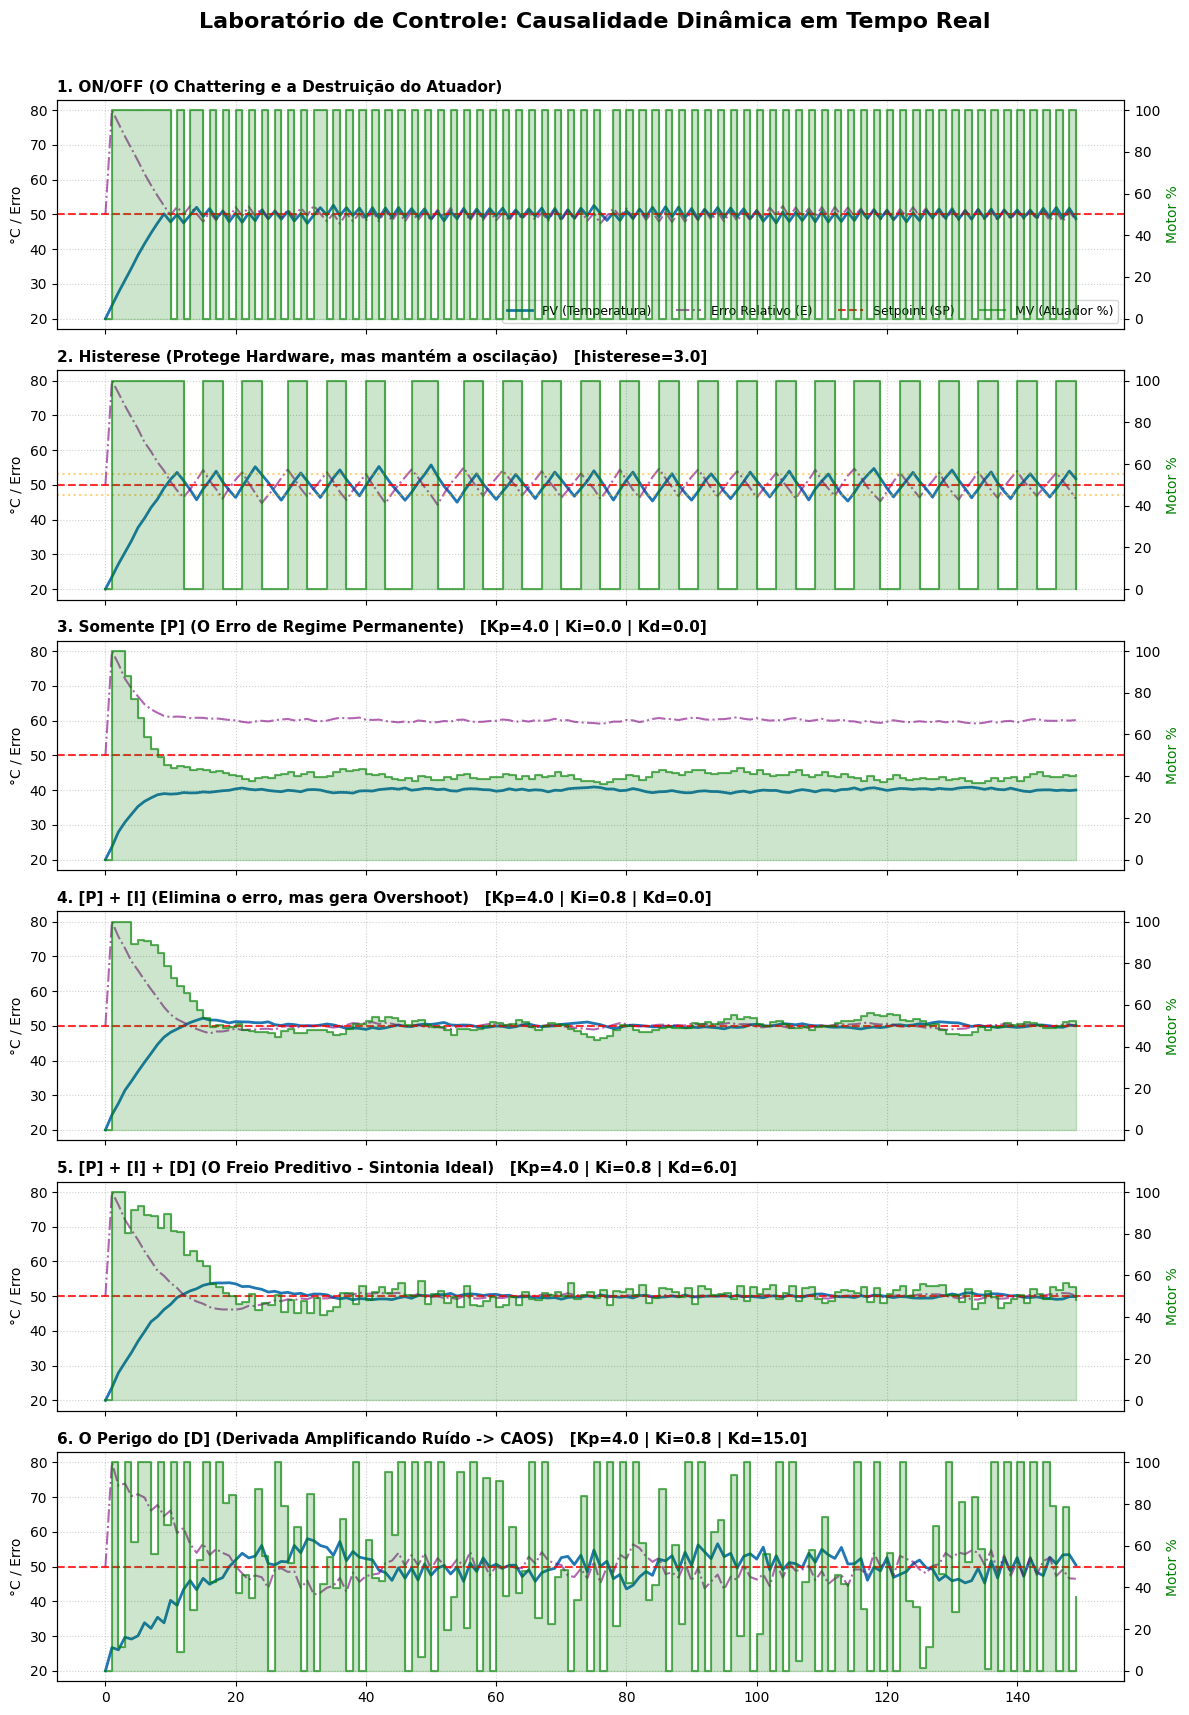

In [ ]:
# ==============================================================================
# PLOTAGEM DO LABORATÓRIO (COMPARATIVO SOCRÁTICO)
# ==============================================================================
modos = [
    {'nome': '1. ON/OFF (O Chattering e a Destruição do Atuador)', 'tipo': 'ON/OFF', 'params': {}},
    {'nome': '2. Histerese (Protege Hardware, mas mantém a oscilação)', 'tipo': 'HISTERESE', 'params': {'histerese': 3.0}},
    {'nome': '3. Somente [P] (O Erro de Regime Permanente)', 'tipo': 'PID', 'params': {'Kp': 4.0, 'Ki': 0.0, 'Kd': 0.0}},
    {'nome': '4. [P] + [I] (Elimina o erro, mas gera Overshoot)', 'tipo': 'PID', 'params': {'Kp': 4.0, 'Ki': 0.8, 'Kd': 0.0}},
    {'nome': '5. [P] + [I] + [D] (O Freio Preditivo - Sintonia Ideal)', 'tipo': 'PID', 'params': {'Kp': 4.0, 'Ki': 0.8, 'Kd': 6.0}},
    {'nome': '6. O Perigo do [D] (Derivada Amplificando Ruído -> CAOS)', 'tipo': 'PID_CAOS', 'params': {'Kp': 4.0, 'Ki': 0.8, 'Kd': 15.0, 'ruido_amp': 4.0}}
]

fig, axs = plt.subplots(len(modos), 1, figsize=(12, 18), sharex=True)
fig.suptitle('Laboratório de Controle: Causalidade Dinâmica em Tempo Real', fontsize=16, fontweight='bold')

t = np.arange(150)
SP = 50.0

for i, config in enumerate(modos):
    T_sim, U_sim, E_sim = simular_controle(config['tipo'], **config['params'])

    # Eixo principal (Variáveis de Processo e Erro)
    axs[i].plot(t, T_sim, label='PV (Temperatura)', color='#1f77b4', lw=2)
    axs[i].plot(t, E_sim + SP, label='Erro Relativo (E)', color='purple', linestyle='-.', lw=1.5, alpha=0.6)
    axs[i].axhline(SP, color='red', linestyle='--', label='Setpoint (SP)', alpha=0.8)

    # Formatação dinâmica para exibir os parâmetros (Kp, Ki, Kd, Histerese) diretamente no título do gráfico
    str_params = " | ".join([f"{chave}={valor}" for chave, valor in config['params'].items() if chave in ['Kp', 'Ki', 'Kd', 'histerese']])
    titulo_grafico = f"{config['nome']}   [{str_params}]" if str_params else config['nome']

    if config['tipo'] == 'HISTERESE':
        axs[i].axhline(SP + config['params']['histerese'], color='orange', linestyle=':', alpha=0.5)
        axs[i].axhline(SP - config['params']['histerese'], color='orange', linestyle=':', alpha=0.5)

    axs[i].set_title(titulo_grafico, fontsize=11, loc='left', color='black', fontweight='bold')
    axs[i].set_ylabel('°C / Erro', fontsize=10)
    axs[i].grid(True, linestyle=':', alpha=0.6)

    # Eixo secundário (Variável Manipulada)
    ax_u = axs[i].twinx()
    ax_u.fill_between(t, 0, U_sim, color='green', alpha=0.2, step='post')
    ax_u.step(t, U_sim, color='green', alpha=0.6, where='post', lw=1.5, label='MV (Atuador %)')
    ax_u.set_ylabel('Motor %', color='green', fontsize=10)
    ax_u.set_ylim(-5, 105)

    if i == 0: # Legenda apenas no primeiro gráfico para não poluir
        linhas_1, labels_1 = axs[i].get_legend_handles_labels()
        linhas_2, labels_2 = ax_u.get_legend_handles_labels()
        axs[i].legend(linhas_1 + linhas_2, labels_1 + labels_2, loc='lower right', ncol=4, fontsize=9)

plt.xlabel('Tempo Discreto [k] (Amostras)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()